In [11]:
import socket, os, torch, subprocess
print("hostname:", socket.gethostname())
print("pid:", os.getpid())
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("cuda device count:", torch.cuda.device_count())
    print("current device:", torch.cuda.current_device())
    subprocess.run(["nvidia-smi", "-L"], check=False)

hostname: gilbreth-d002.rcac.purdue.edu
pid: 79641
cuda available: True
cuda device count: 1
current device: 0
GPU 0: NVIDIA A30 (UUID: GPU-9f803576-0185-fea0-daee-42754e4aef4c)


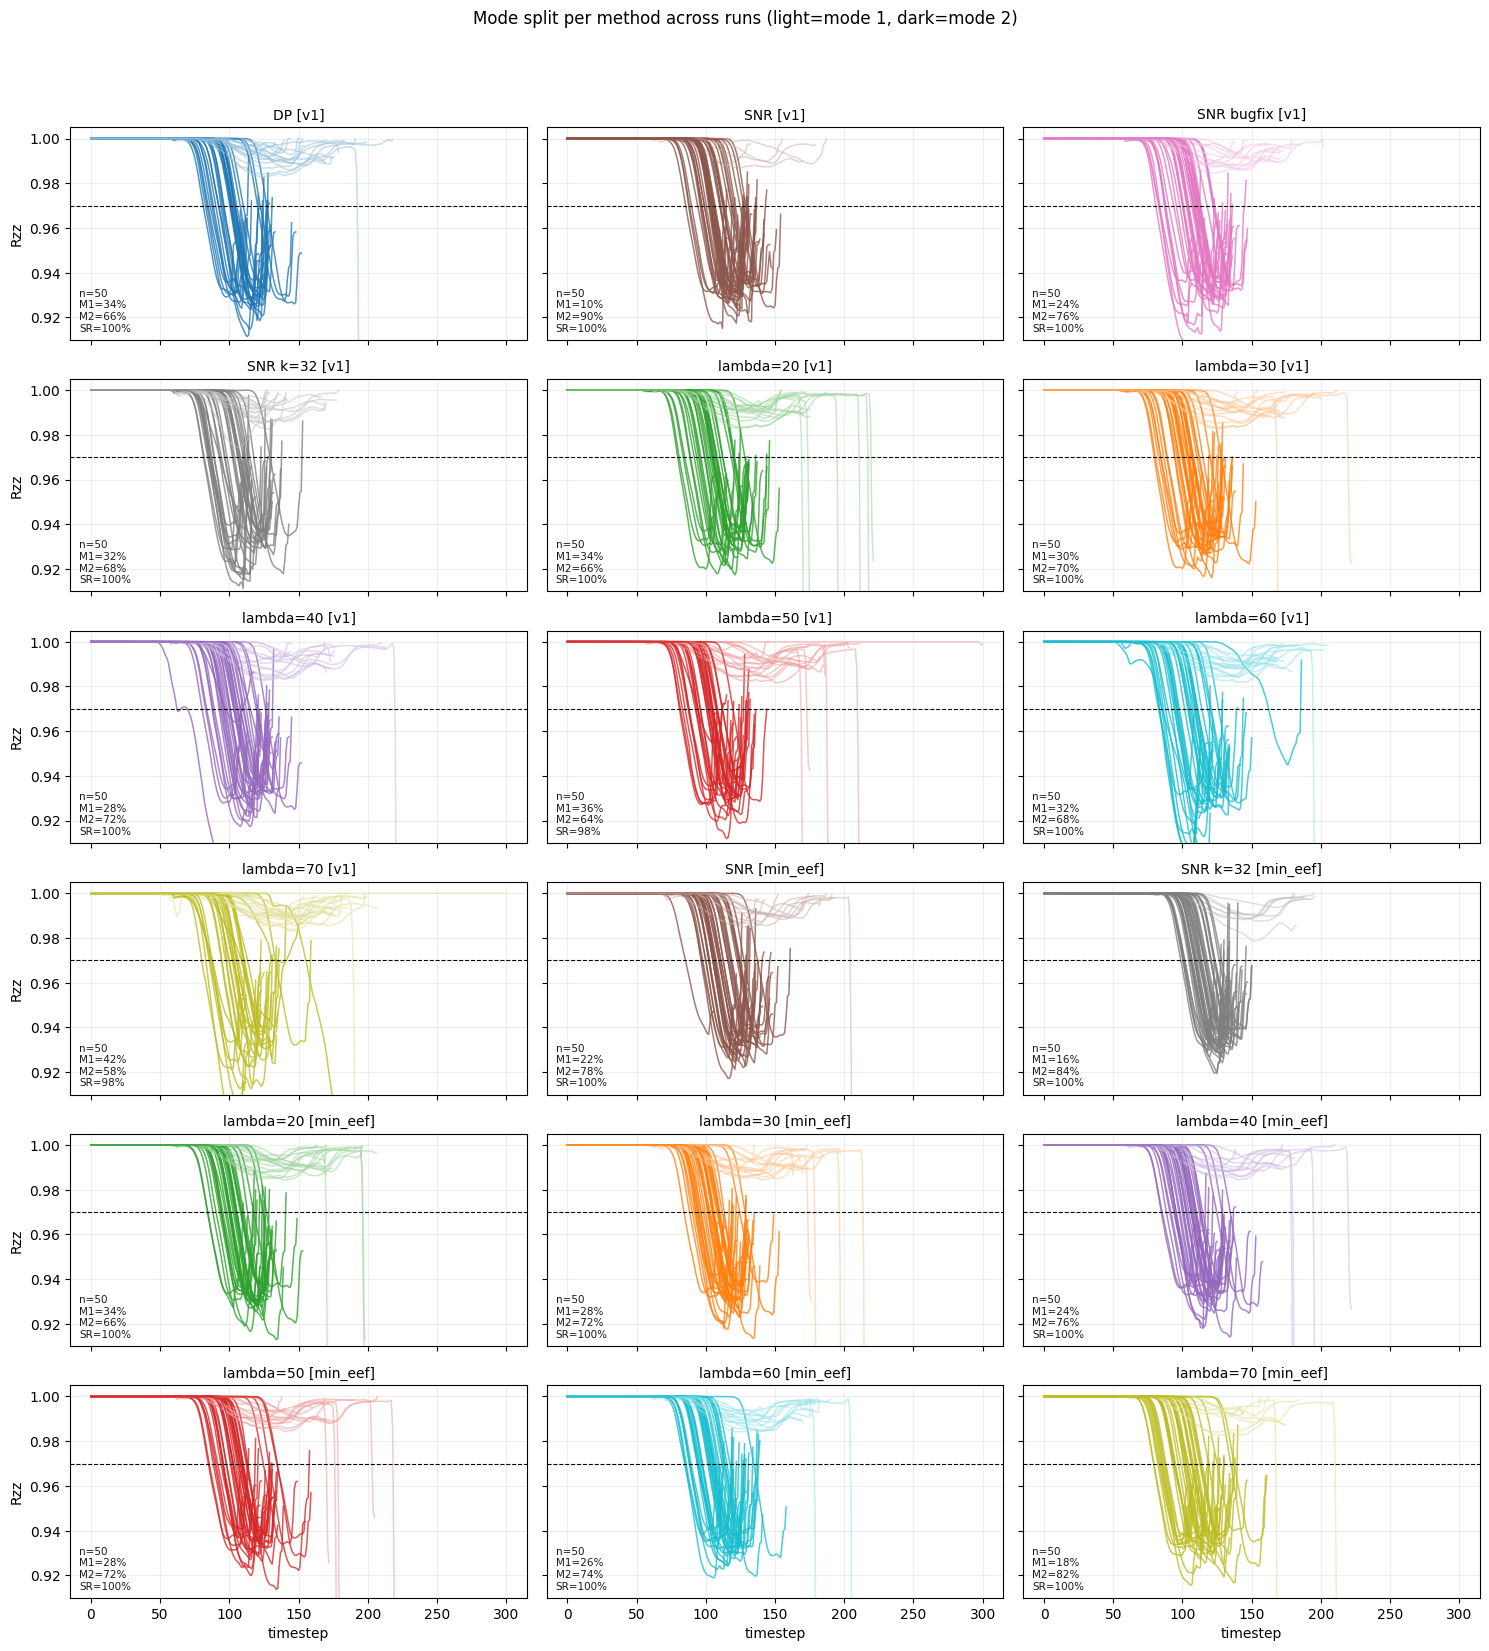

run roots:
  - v1_s1_50: /scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/20260407_210830_v1_s1_50
  - min_eef_rzz_guidance: /scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/min_eef_rzz_guidance
env: n16h300r60g1bYfYv1 | threshold: 0.97 | core window: [0.00, 0.90]
mode 2 trigger: >= 3 violations in core window

Run        Method                N   Mode1 %   Mode2 %  Success %       Avg_Rzz (core)      Avg_EEF_Rzz     Timestep_VFrac(core)      Avg_Rzz M1 (core)      Avg_Rzz M2 (core)
----------------------------------------------------------------------------------------------------------------------------------------------------------------------
v1         DP                   50    34.00%    66.00%    100.00%               0.9945          -0.9951                   0.0733                 0.9975                 0.9930
v1         SNR                  50    10.00%    90.00%    100.00%     -0.0001 (0.9944) +0.0003 (-0.9948)         +0.0118 (0.0852

In [12]:
# Mode split per method across multiple runs: method-specific color family, light=mode 1, dark=mode 2.

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

base_dir = Path("/scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison")
env_name = "n16h300r60g1bYfYv1"
seed_range = range(1, 51)
threshold = 0.97
ymin, ymax = 0.91, 1.005

core_start_fraction = 0.00
core_end_fraction = 0.90
violation_steps_for_mode2 = 3

# Analyze both requested runs together; keep v1 first for plotting and table display.
run_roots = [
    ("v1_s1_50", base_dir / "20260407_210830_v1_s1_50"),
    ("min_eef_rzz_guidance", base_dir / "min_eef_rzz_guidance"),
]

for run_tag, run_root in run_roots:
    if not run_root.exists():
        raise RuntimeError(f"Run directory not found: {run_root}")

method_labels = {
    "dp_base": "DP",
    "snr_k8": "SNR",
    "snr_k8_bugfix": "SNR bugfix",
    "snr_k32": "SNR k=32",
    "dp_guidance_l20": "lambda=20",
    "dp_guidance_l30": "lambda=30",
    "dp_guidance_l40": "lambda=40",
    "dp_guidance_l50": "lambda=50",
    "dp_guidance_l60": "lambda=60",
    "dp_guidance_l70": "lambda=70",
}

# One base color per method; mode 1 uses a lighter tint.
method_base_colors = {
    "dp_base": "#1f77b4",
    "snr_k8": "#8c564b",
    "snr_k8_bugfix": "#e377c2",
    "snr_k32": "#7f7f7f",
    "dp_guidance_l20": "#2ca02c",
    "dp_guidance_l30": "#ff7f0e",
    "dp_guidance_l40": "#9467bd",
    "dp_guidance_l50": "#d62728",
    "dp_guidance_l60": "#17becf",
    "dp_guidance_l70": "#bcbd22",
}

preferred_order = [
    "dp_base",
    "snr_k8",
    "snr_k8_bugfix",
    "snr_k32",
    "dp_guidance_l20",
    "dp_guidance_l30",
    "dp_guidance_l40",
    "dp_guidance_l50",
    "dp_guidance_l60",
    "dp_guidance_l70",
]

run_tag_label = {
    "min_eef_rzz_guidance": "min_eef",
    "v1_s1_50": "v1",
}


def lighten_color(color, amount=0.6):
    r, g, b = mcolors.to_rgb(color)
    return (1 - amount) + amount * r, (1 - amount) + amount * g, (1 - amount) + amount * b


def _rotation_6d_to_rzz_numpy(rot6d: np.ndarray) -> np.ndarray:
    rot6d = np.asarray(rot6d, dtype=np.float32)
    a1 = rot6d[:, 0:3]
    a2 = rot6d[:, 3:6]

    b1 = a1 / (np.linalg.norm(a1, axis=1, keepdims=True) + 1e-8)
    a2_proj = np.sum(b1 * a2, axis=1, keepdims=True) * b1
    b2_raw = a2 - a2_proj
    b2 = b2_raw / (np.linalg.norm(b2_raw, axis=1, keepdims=True) + 1e-8)
    b3 = np.cross(b1, b2)

    # Rzz is the z-component of the third rotation axis.
    return b3[:, 2]


def _load_numeric_arrays(npz_path):
    data = np.load(npz_path)
    can_rzz = np.asarray(data["rzz_mujoco"], dtype=np.float32)
    states = np.asarray(data["states"], dtype=np.float32) if "states" in data.files else None
    return can_rzz, states


def _load_method_rollouts(run_root, method_slug):
    seed_to_rzz = {}
    seed_to_states = {}
    seed_to_success = {}

    rows_path = run_root / method_slug / "rollout_rows.jsonl"
    if rows_path.exists():
        with rows_path.open("r", encoding="utf-8") as f:
            rows = [json.loads(line) for line in f if line.strip()]

        for r in rows:
            if r.get("init_name") != env_name:
                continue
            seed = int(r.get("seed", -1))
            if seed not in seed_range:
                continue

            npz_path = run_root / method_slug / f"{env_name}__seed_{seed:02d}" / "rollout_numeric.npz"
            if not npz_path.exists():
                continue

            can_rzz, states = _load_numeric_arrays(npz_path)
            seed_to_rzz[seed] = can_rzz
            if states is not None:
                seed_to_states[seed] = states
            seed_to_success[seed] = float(bool(r.get("success", False)))
        return seed_to_rzz, seed_to_states, seed_to_success

    # Fallback for folders without rollout_rows.jsonl (e.g. snr_k8_bugfix).
    for seed in seed_range:
        candidate_dirs = [
            run_root / method_slug / f"{env_name}__seed_{seed:02d}",
            run_root / method_slug / f"{env_name}_seed{seed}",
            run_root / method_slug / f"{env_name}_seed_{seed:02d}",
        ]
        rollout_dir = next((d for d in candidate_dirs if d.exists()), None)
        if rollout_dir is None:
            continue

        npz_path = rollout_dir / "rollout_numeric.npz"
        if not npz_path.exists():
            continue

        can_rzz, states = _load_numeric_arrays(npz_path)
        seed_to_rzz[seed] = can_rzz
        if states is not None:
            seed_to_states[seed] = states

        stats_path = rollout_dir / "rollout_stats.json"
        if stats_path.exists():
            with stats_path.open("r", encoding="utf-8") as f:
                stats = json.load(f)
            seed_to_success[seed] = float(bool(stats.get("success", False)))

    return seed_to_rzz, seed_to_states, seed_to_success


method_entries = []
for run_tag, run_root in run_roots:
    methods = [p.name for p in sorted(run_root.iterdir()) if p.is_dir()]
    methods = [m for m in preferred_order if m in methods] + [m for m in methods if m not in preferred_order]
    for method_slug in methods:
        method_entries.append({
            "run_tag": run_tag,
            "run_root": run_root,
            "method_slug": method_slug,
        })

n_methods = len(method_entries)
if n_methods == 0:
    raise RuntimeError("No method directories found across selected runs.")

ncols = 3
nrows = int(np.ceil(n_methods / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 2.8 * nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

summary_rows = []

for ax, entry in zip(axes, method_entries):
    run_tag = entry["run_tag"]
    run_root = entry["run_root"]
    method_slug = entry["method_slug"]

    seed_to_rzz, seed_to_states, seed_to_success = _load_method_rollouts(run_root, method_slug)

    seed_to_mode = {}
    per_rollout_core_mean_rzz = []
    per_rollout_core_mean_eef_rzz = []
    per_rollout_core_timestep_vfrac = []
    per_mode_core_mean_rzz = {1: [], 2: []}

    for seed, rzz in seed_to_rzz.items():
        n = len(rzz)
        i0 = max(0, min(n - 1, int(n * core_start_fraction)))
        i1 = min(n, max(i0 + 1, int(n * core_end_fraction)))
        rzz_core = rzz[i0:i1]

        violation_count = int(np.sum(rzz_core < threshold))
        seed_to_mode[seed] = 2 if violation_count >= violation_steps_for_mode2 else 1

        core_mean_rzz = float(np.mean(rzz_core))
        per_rollout_core_mean_rzz.append(core_mean_rzz)
        per_rollout_core_timestep_vfrac.append(float(np.mean(rzz_core < threshold)))
        per_mode_core_mean_rzz[seed_to_mode[seed]].append(core_mean_rzz)

        states = seed_to_states.get(seed)
        if states is not None and states.ndim == 2 and states.shape[1] >= 27 and len(states) > 0:
            eef_rot6d = states[:, 21:27]
            eef_rzz = _rotation_6d_to_rzz_numpy(eef_rot6d)
            n_eef = len(eef_rzz)
            j0 = max(0, min(n_eef - 1, int(n_eef * core_start_fraction)))
            j1 = min(n_eef, max(j0 + 1, int(n_eef * core_end_fraction)))
            per_rollout_core_mean_eef_rzz.append(float(np.mean(eef_rzz[j0:j1])))

    base_color = method_base_colors.get(method_slug, "#4c4c4c")
    light_color = lighten_color(base_color, amount=0.45)
    dark_color = mcolors.to_rgb(base_color)

    for seed in seed_range:
        rzz = seed_to_rzz.get(seed)
        if rzz is None:
            continue

        mode = seed_to_mode[seed]
        color = light_color if mode == 1 else dark_color
        alpha = 0.55 if mode == 1 else 0.78
        ax.plot(rzz, color=color, lw=1.1, alpha=alpha)

    ax.axhline(threshold, color="black", linestyle="--", linewidth=0.8)
    run_label = run_tag_label.get(run_tag, run_tag)
    ax.set_title(f"{method_labels.get(method_slug, method_slug)} [{run_label}]", fontsize=10)
    ax.grid(alpha=0.2)
    ax.set_ylim(ymin, ymax)

    total = len(seed_to_rzz)
    mode1_count = sum(1 for s in seed_to_rzz if seed_to_mode.get(s) == 1)
    mode2_count = sum(1 for s in seed_to_rzz if seed_to_mode.get(s) == 2)
    mode1_pct = (100.0 * mode1_count / total) if total else float("nan")
    mode2_pct = (100.0 * mode2_count / total) if total else float("nan")
    success_vals = [seed_to_success[s] for s in seed_to_rzz if s in seed_to_success]
    success_pct = (100.0 * float(np.mean(success_vals))) if success_vals else float("nan")

    avg_rzz_core = float(np.mean(per_rollout_core_mean_rzz)) if per_rollout_core_mean_rzz else float("nan")
    avg_eef_rzz_core = (
        float(np.mean(per_rollout_core_mean_eef_rzz))
        if per_rollout_core_mean_eef_rzz
        else float("nan")
    )
    timestep_vfrac_core = float(np.mean(per_rollout_core_timestep_vfrac)) if per_rollout_core_timestep_vfrac else float("nan")
    avg_rzz_mode1 = float(np.mean(per_mode_core_mean_rzz[1])) if per_mode_core_mean_rzz[1] else float("nan")
    avg_rzz_mode2 = float(np.mean(per_mode_core_mean_rzz[2])) if per_mode_core_mean_rzz[2] else float("nan")

    summary_rows.append(
        {
            "run_tag": run_tag,
            "method_slug": method_slug,
            "label": method_labels.get(method_slug, method_slug),
            "N": total,
            "mode1_pct": mode1_pct,
            "mode2_pct": mode2_pct,
            "success_pct": success_pct,
            "avg_rzz_core": avg_rzz_core,
            "avg_eef_rzz_core": avg_eef_rzz_core,
            "avg_rzz_mode1": avg_rzz_mode1,
            "avg_rzz_mode2": avg_rzz_mode2,
            "timestep_vfrac_core": timestep_vfrac_core,
        }
    )

    ax.text(
        0.02,
        0.04,
        f"n={total}\nM1={mode1_pct:.0f}%\nM2={mode2_pct:.0f}%\nSR={success_pct:.0f}%",
        transform=ax.transAxes,
        fontsize=7.5,
        alpha=0.9,
    )

# Hide unused axes.
for ax in axes[n_methods:]:
    ax.axis("off")

for r in range(nrows):
    axes[r * ncols].set_ylabel("Rzz")
for c in range(ncols):
    idx = (nrows - 1) * ncols + c
    if idx < len(axes):
        axes[idx].set_xlabel("timestep")

fig.suptitle("Mode split per method across runs (light=mode 1, dark=mode 2)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("run roots:")
for run_tag, run_root in run_roots:
    print(f"  - {run_tag}: {run_root}")
print(f"env: {env_name} | threshold: {threshold:.2f} | core window: [{core_start_fraction:.2f}, {core_end_fraction:.2f}]")
print(f"mode 2 trigger: >= {violation_steps_for_mode2} violations in core window")
print()

# Use v1 DP as table baseline and print deltas for all other rows.
base_row = next((r for r in summary_rows if r["run_tag"] == "v1_s1_50" and r["method_slug"] == "dp_base"), None)
if base_row is None:
    print("No v1 DP base found; showing absolute metrics (no deltas).")

base_avg_rzz = base_row["avg_rzz_core"] if base_row is not None else None
base_avg_eef_rzz = base_row["avg_eef_rzz_core"] if base_row is not None else None
base_rzz_mode1 = base_row["avg_rzz_mode1"] if base_row is not None else None
base_rzz_mode2 = base_row["avg_rzz_mode2"] if base_row is not None else None
base_tvf = base_row["timestep_vfrac_core"] if base_row is not None else None

print(
    f"{'Run':<10} {'Method':<18} {'N':>4} {'Mode1 %':>9} {'Mode2 %':>9} {'Success %':>10} {'Avg_Rzz (core)':>20} {'Avg_EEF_Rzz':>16} {'Timestep_VFrac(core)':>24} {'Avg_Rzz M1 (core)':>22} {'Avg_Rzz M2 (core)':>22}"
)
print("-" * 166)

for row in summary_rows:
    run_col = run_tag_label.get(row["run_tag"], row["run_tag"])
    label = row["label"]
    n = row["N"]
    m1 = row["mode1_pct"]
    m2 = row["mode2_pct"]
    sr = row["success_pct"]
    avg_rzz = row["avg_rzz_core"]
    avg_eef_rzz = row["avg_eef_rzz_core"]
    avg_rzz_mode1 = row["avg_rzz_mode1"]
    avg_rzz_mode2 = row["avg_rzz_mode2"]
    tvf = row["timestep_vfrac_core"]

    is_base = base_row is not None and row["run_tag"] == "v1_s1_50" and row["method_slug"] == "dp_base"

    if base_row is None or is_base:
        avg_rzz_col = f"{avg_rzz:.4f}"
        avg_eef_rzz_col = f"{avg_eef_rzz:.4f}" if np.isfinite(avg_eef_rzz) else "nan"
        tvf_col = f"{tvf:.4f}"
        avg_rzz_mode1_col = f"{avg_rzz_mode1:.4f}"
        avg_rzz_mode2_col = f"{avg_rzz_mode2:.4f}"
    else:
        delta_rzz = avg_rzz - base_avg_rzz
        delta_rzz_mode1 = avg_rzz_mode1 - base_rzz_mode1
        delta_rzz_mode2 = avg_rzz_mode2 - base_rzz_mode2
        delta_tvf = tvf - base_tvf
        avg_rzz_col = f"{delta_rzz:+.4f} ({avg_rzz:.4f})"
        if np.isfinite(avg_eef_rzz) and np.isfinite(base_avg_eef_rzz):
            delta_eef_rzz = avg_eef_rzz - base_avg_eef_rzz
            avg_eef_rzz_col = f"{delta_eef_rzz:+.4f} ({avg_eef_rzz:.4f})"
        else:
            avg_eef_rzz_col = "nan"
        tvf_col = f"{delta_tvf:+.4f} ({tvf:.4f})"
        avg_rzz_mode1_col = f"{delta_rzz_mode1:+.4f} ({avg_rzz_mode1:.4f})"
        avg_rzz_mode2_col = f"{delta_rzz_mode2:+.4f} ({avg_rzz_mode2:.4f})"

    print(
        f"{run_col:<10} {label:<18} {n:>4} {m1:>8.2f}% {m2:>8.2f}% {sr:>9.2f}% {avg_rzz_col:>20} {avg_eef_rzz_col:>16} {tvf_col:>24} {avg_rzz_mode1_col:>22} {avg_rzz_mode2_col:>22}"
    )

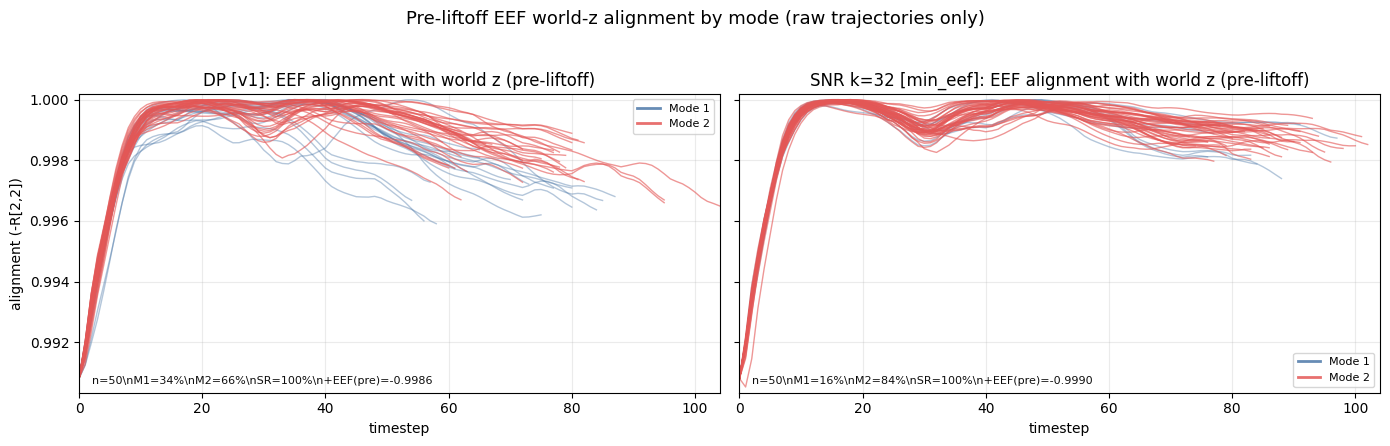

env: n16h300r60g1bYfYv1 | threshold: 0.97 | core window: [0.00, 0.90]
mode 2 trigger: >= 3 can-Rzz violations in core window
shared xlim: (0, 104) | shared ylim: (0.9903, 1.0002)

DP         [v1] | N=50 | M1=17 | M2=33 | SR=100.0% | closure mean= 74.34 std=10.75 | +EEF(pre)=-0.998613 | +EEF(core)=-0.995059
SNR k=32   [min_eef] | N=50 | M1= 8 | M2=42 | SR=100.0% | closure mean= 86.56 std= 7.42 | +EEF(pre)=-0.998975 | +EEF(core)=-0.995928

Average +EEF_Rzz objective (lower is better)
Method             Run            Pre-liftoff (+EEF)     Full core (+EEF)
--------------------------------------------------------------------------
DP                 v1                      -0.998613            -0.995059
SNR k=32           min_eef                 -0.998975            -0.995928


In [15]:
# Pre-liftoff EEF world-z alignment: DP (left, v1 run) vs SNR k=32 (right, min_eef run).

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

base_dir = Path("/scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison")
env_name = "n16h300r60g1bYfYv1"
seed_range = range(1, 51)

threshold = 0.97
core_start_fraction = 0.00
core_end_fraction = 0.90
violation_steps_for_mode2 = 3

method_specs = [
    {
        "method_slug": "dp_base",
        "label": "DP",
        "run_root": base_dir / "20260407_210830_v1_s1_50",
        "run_tag": "v1",
    },
    {
        "method_slug": "snr_k32",
        "label": "SNR k=32",
        "run_root": base_dir / "min_eef_rzz_guidance",
        "run_tag": "min_eef",
    },
]

mode_colors = {
    1: "#4C78A8",
    2: "#E45756",
}

for spec in method_specs:
    if not spec["run_root"].exists():
        raise FileNotFoundError(f"Missing run root: {spec['run_root']}")


def reconstruct_rotation_matrix_from_6d(q6d: np.ndarray) -> np.ndarray:
    q6d = np.asarray(q6d, dtype=np.float32)
    a1 = q6d[:3]
    a2 = q6d[3:6]

    b1 = a1 / (np.linalg.norm(a1) + 1e-8)
    a2_proj = np.dot(b1, a2) * b1
    b2_raw = a2 - a2_proj
    b2 = b2_raw / (np.linalg.norm(b2_raw) + 1e-8)
    b3 = np.cross(b1, b2)
    return np.stack([b1, b2, b3], axis=1)


def _load_rollout_row_index(rows_path: Path):
    seed_to_success = {}
    if not rows_path.exists():
        return seed_to_success
    with rows_path.open("r", encoding="utf-8") as f:
        rows = [json.loads(line) for line in f if line.strip()]
    for r in rows:
        if r.get("init_name") != env_name:
            continue
        seed = int(r.get("seed", -1))
        if seed in seed_range:
            seed_to_success[seed] = float(bool(r.get("success", False)))
    return seed_to_success


def _load_method_data(run_root: Path, method_slug: str):
    method_root = run_root / method_slug
    if not method_root.exists():
        raise FileNotFoundError(f"Missing method directory: {method_root}")

    seed_to_states = {}
    seed_to_can_rzz = {}
    seed_to_success = _load_rollout_row_index(method_root / "rollout_rows.jsonl")

    for seed in seed_range:
        candidate_dirs = [
            method_root / f"{env_name}__seed_{seed:02d}",
            method_root / f"{env_name}_seed{seed}",
            method_root / f"{env_name}_seed_{seed:02d}",
        ]
        rollout_dir = next((d for d in candidate_dirs if d.exists()), None)
        if rollout_dir is None:
            continue

        npz_path = rollout_dir / "rollout_numeric.npz"
        if not npz_path.exists():
            continue

        data = np.load(npz_path)
        if "states" not in data.files or "rzz_mujoco" not in data.files:
            continue

        seed_to_states[seed] = np.asarray(data["states"], dtype=np.float32)
        seed_to_can_rzz[seed] = np.asarray(data["rzz_mujoco"], dtype=np.float32)

        stats_path = rollout_dir / "rollout_stats.json"
        if seed not in seed_to_success and stats_path.exists():
            with stats_path.open("r", encoding="utf-8") as f:
                stats = json.load(f)
            seed_to_success[seed] = float(bool(stats.get("success", False)))

    return seed_to_states, seed_to_can_rzz, seed_to_success


def _closure_timestep(states: np.ndarray) -> int:
    gripper_qpos = np.asarray(states[:, 27:29], dtype=np.float32)
    gripper_dist = np.linalg.norm(gripper_qpos, axis=1)
    gradient = np.gradient(gripper_dist)

    n = len(gripper_dist)
    start_idx = 10
    end_idx = n - 10 if n > 20 else n
    if start_idx >= end_idx:
        return n

    local_idx = int(np.argmin(gradient[start_idx:end_idx]))
    return start_idx + local_idx


def _mode_from_can_rzz(can_rzz: np.ndarray) -> int:
    n = len(can_rzz)
    i0 = max(0, min(n - 1, int(n * core_start_fraction)))
    i1 = min(n, max(i0 + 1, int(n * core_end_fraction)))
    can_rzz_core = can_rzz[i0:i1]
    violation_count = int(np.sum(can_rzz_core < threshold))
    return 2 if violation_count >= violation_steps_for_mode2 else 1


method_results = {}
global_xmax = 1
global_ymin = np.inf
global_ymax = -np.inf

for spec in method_specs:
    method_slug = spec["method_slug"]
    run_root = spec["run_root"]

    seed_to_states, seed_to_can_rzz, seed_to_success = _load_method_data(run_root, method_slug)

    series_by_mode = {1: [], 2: []}
    closure_idxs = []
    mode_counts = {1: 0, 2: 0}
    success_vals = []
    plus_eef_rzz_scores_pre = []
    plus_eef_rzz_scores_core = []

    for seed in seed_range:
        states = seed_to_states.get(seed)
        can_rzz = seed_to_can_rzz.get(seed)
        if states is None or can_rzz is None or states.ndim != 2 or states.shape[1] < 29:
            continue

        closure_idx = _closure_timestep(states)
        closure_idxs.append(closure_idx)

        mode = _mode_from_can_rzz(can_rzz)
        mode_counts[mode] += 1

        if seed in seed_to_success:
            success_vals.append(seed_to_success[seed])

        eef_q6d_full = np.asarray(states[:, 21:27], dtype=np.float32)
        align_z_full = np.empty((len(eef_q6d_full),), dtype=np.float32)
        for i, q6d in enumerate(eef_q6d_full):
            R = reconstruct_rotation_matrix_from_6d(q6d)
            align_z_full[i] = -R[2, 2]

        # +EEF_Rzz objective uses eef_rzz = -alignment_z.
        eef_rzz_full = -align_z_full

        n_full = len(eef_rzz_full)
        k0 = max(0, min(n_full - 1, int(n_full * core_start_fraction)))
        k1 = min(n_full, max(k0 + 1, int(n_full * core_end_fraction)))
        eef_rzz_core = eef_rzz_full[k0:k1]

        align_z_pre = align_z_full[:closure_idx]
        if len(align_z_pre) > 0:
            series_by_mode[mode].append(align_z_pre)
            global_xmax = max(global_xmax, len(align_z_pre) - 1)
            global_ymin = min(global_ymin, float(np.min(align_z_pre)))
            global_ymax = max(global_ymax, float(np.max(align_z_pre)))
            eef_rzz_pre = -align_z_pre
            plus_eef_rzz_scores_pre.append(float(np.mean(eef_rzz_pre)))

        if len(eef_rzz_core) > 0:
            plus_eef_rzz_scores_core.append(float(np.mean(eef_rzz_core)))

    method_results[method_slug] = {
        "label": spec["label"],
        "run_tag": spec["run_tag"],
        "run_root": run_root,
        "series_by_mode": series_by_mode,
        "mode_counts": mode_counts,
        "closure_idxs": closure_idxs,
        "success_vals": success_vals,
        "plus_eef_rzz_scores_pre": plus_eef_rzz_scores_pre,
        "plus_eef_rzz_scores_core": plus_eef_rzz_scores_core,
    }

if not np.isfinite(global_ymin) or not np.isfinite(global_ymax):
    raise RuntimeError("No pre-liftoff alignment data found.")

# Shared axis limits across both subplots.
y_pad = 0.02 * max(1e-6, global_ymax - global_ymin)
shared_xlim = (0, global_xmax)
shared_ylim = (global_ymin - y_pad, global_ymax + y_pad)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True, sharey=True)

for ax, spec in zip(axes, method_specs):
    method_slug = spec["method_slug"]
    result = method_results[method_slug]
    series_by_mode = result["series_by_mode"]

    for mode in [1, 2]:
        color = mode_colors[mode]
        alpha = 0.42 if mode == 1 else 0.62
        for s in series_by_mode[mode]:
            ax.plot(s, color=color, lw=1.0, alpha=alpha)

    m1 = result["mode_counts"][1]
    m2 = result["mode_counts"][2]
    total = m1 + m2
    sr = 100.0 * float(np.mean(result["success_vals"])) if result["success_vals"] else float("nan")
    m1_pct = 100.0 * m1 / total if total else float("nan")
    m2_pct = 100.0 * m2 / total if total else float("nan")

    pre_vals = result["plus_eef_rzz_scores_pre"]
    core_vals = result["plus_eef_rzz_scores_core"]
    obj_pre = float(np.mean(pre_vals)) if pre_vals else float("nan")
    obj_core = float(np.mean(core_vals)) if core_vals else float("nan")

    ax.text(
        0.02,
        0.03,
        f"n={total}\\nM1={m1_pct:.0f}%\\nM2={m2_pct:.0f}%\\nSR={sr:.0f}%\\n+EEF(pre)={obj_pre:.4f}",
        transform=ax.transAxes,
        fontsize=8,
        alpha=0.95,
    )

    ax.plot([], [], color=mode_colors[1], lw=2.0, alpha=0.85, label="Mode 1")
    ax.plot([], [], color=mode_colors[2], lw=2.0, alpha=0.85, label="Mode 2")

    ax.set_title(f"{result['label']} [{result['run_tag']}]: EEF alignment with world z (pre-liftoff)")
    ax.set_xlabel("timestep")
    ax.set_xlim(*shared_xlim)
    ax.set_ylim(*shared_ylim)
    ax.grid(alpha=0.25)
    ax.legend(frameon=True, fontsize=8, loc="best")

axes[0].set_ylabel("alignment (-R[2,2])")
fig.suptitle("Pre-liftoff EEF world-z alignment by mode (raw trajectories only)", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print(f"env: {env_name} | threshold: {threshold:.2f} | core window: [{core_start_fraction:.2f}, {core_end_fraction:.2f}]")
print(f"mode 2 trigger: >= {violation_steps_for_mode2} can-Rzz violations in core window")
print(f"shared xlim: {shared_xlim} | shared ylim: ({shared_ylim[0]:.4f}, {shared_ylim[1]:.4f})")
print()

for spec in method_specs:
    method_slug = spec["method_slug"]
    result = method_results[method_slug]
    m1 = result["mode_counts"][1]
    m2 = result["mode_counts"][2]
    total = m1 + m2
    sr = 100.0 * float(np.mean(result["success_vals"])) if result["success_vals"] else float("nan")
    closure_idxs = result["closure_idxs"]
    closure_mean = float(np.mean(closure_idxs)) if closure_idxs else float("nan")
    closure_std = float(np.std(closure_idxs)) if closure_idxs else float("nan")
    pre_vals = result["plus_eef_rzz_scores_pre"]
    core_vals = result["plus_eef_rzz_scores_core"]
    obj_pre = float(np.mean(pre_vals)) if pre_vals else float("nan")
    obj_core = float(np.mean(core_vals)) if core_vals else float("nan")
    print(
        f"{result['label']:<10} [{result['run_tag']}] | N={total:>2} | M1={m1:>2} | M2={m2:>2} | SR={sr:>5.1f}% | "
        f"closure mean={closure_mean:>6.2f} std={closure_std:>5.2f} | +EEF(pre)={obj_pre:>8.6f} | +EEF(core)={obj_core:>8.6f}"
    )

print()
print("Average +EEF_Rzz objective (lower is better)")
print(f"{'Method':<18} {'Run':<10} {'Pre-liftoff (+EEF)':>22} {'Full core (+EEF)':>20}")
print("-" * 74)
for spec in method_specs:
    method_slug = spec["method_slug"]
    result = method_results[method_slug]
    pre_vals = result["plus_eef_rzz_scores_pre"]
    core_vals = result["plus_eef_rzz_scores_core"]
    pre_avg = float(np.mean(pre_vals)) if pre_vals else float("nan")
    core_avg = float(np.mean(core_vals)) if core_vals else float("nan")
    print(f"{result['label']:<18} {result['run_tag']:<10} {pre_avg:>22.6f} {core_avg:>20.6f}")